# Exploratory Data Analysis on Retail Sales Data

## Oasis Infobyte Internship

  Name: Prince Kumar  
  Track: Data Analytics  
  Task: Task 1 - EDA on Retail Sales Data  




## Objective

The objective of this project is to perform Exploratory Data Analysis (EDA)
on a retail sales dataset to identify sales patterns, understand customer
behaviour, analyze product categories, and discover actionable business insights.

The analysis focuses on understanding sales trends over time, customer
demographics, product category performance, and relationships between
different numerical variables.



## Tools & Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab



## Dataset

The dataset contains retail transaction information including transaction
details, customer demographics, product categories, quantity purchased,
price per unit, and total transaction amount.



## Key Areas of Analysis

1. Initial data inspection and data quality checking
2. Descriptive statistical analysis
3. Monthly and quarterly sales trends
4. Customer age-group and gender analysis
5. Product category performance analysis
6. Correlation analysis using a heatmap
7. Additional visualization for identifying non-obvious insights
8. Business insights and actionable recommendations

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
sns.set_theme()

In [6]:
from google.colab import files

uploaded = files.upload()

Saving retail_sales_dataset.csv to retail_sales_dataset.csv


In [10]:
df = pd.read_csv("retail_sales_dataset.csv")

In [8]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,24-11-2023,CUST001,Male,34,Beauty,3,50,150
1,2,27-02-2023,CUST002,Female,26,Clothing,2,500,1000
2,3,13-01-2023,CUST003,Male,50,Electronics,1,30,30
3,4,21-05-2023,CUST004,Male,37,Clothing,1,500,500
4,5,06-05-2023,CUST005,Male,30,Beauty,2,50,100


In [12]:
df.shape

(1000, 9)

In [41]:
df.dtypes


,0
Transaction ID,int64
Date,datetime64[ns]
Customer ID,object
Gender,object
Age,int64
Product Category,object
Quantity,int64
Price per Unit,int64
Total Amount,int64
Age Group,category


In [14]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


##Descriptive Statistics

In this section, descriptive statistics are calculated for the numerical
variables in the dataset. Mean, median, mode, and standard deviation
are used to understand the central tendency and variability of the data.

In [17]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [18]:
df.mean(numeric_only=True)

,0
Transaction ID,500.500
Age,41.392
Quantity,2.514
Price per Unit,179.890
Total Amount,456.000


In [19]:
df.median(numeric_only=True)


,0
Transaction ID,500.5
Age,42.0
Quantity,3.0
Price per Unit,50.0
Total Amount,135.0


In [20]:
df.mode(numeric_only=True).iloc[0]

,0
Transaction ID,1.0
Age,43.0
Quantity,4.0
Price per Unit,50.0
Total Amount,50.0


In [21]:
df.std(numeric_only=True)


,0
Transaction ID,288.819436
Age,13.681430
Quantity,1.132734
Price per Unit,189.681356
Total Amount,559.997632


In [22]:
stats = pd.DataFrame({
    'Mean': df.mean(numeric_only=True),
    'Median': df.median(numeric_only=True),
    'Mode': df.mode(numeric_only=True).iloc[0],
    'Standard Deviation': df.std(numeric_only=True)
})

stats

,Mean,Median,Mode,Standard Deviation
Transaction ID,500.500,500.5,1.0,288.819436
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


## 3. Time Series Analysis

In this section, sales trends are analyzed over time using monthly and
quarterly aggregations. Line charts are used to identify changes and
patterns in total sales over different time periods.

In [24]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [25]:
monthly_sales = df.resample('ME', on='Date')['Total Amount'].sum()

monthly_sales

,Total Amount
Date,
2023-01-31,35450
2023-02-28,44060
2023-03-31,28990
2023-04-30,33870
2023-05-31,53150
2023-06-30,36715
2023-07-31,35465
2023-08-31,36960
2023-09-30,23620


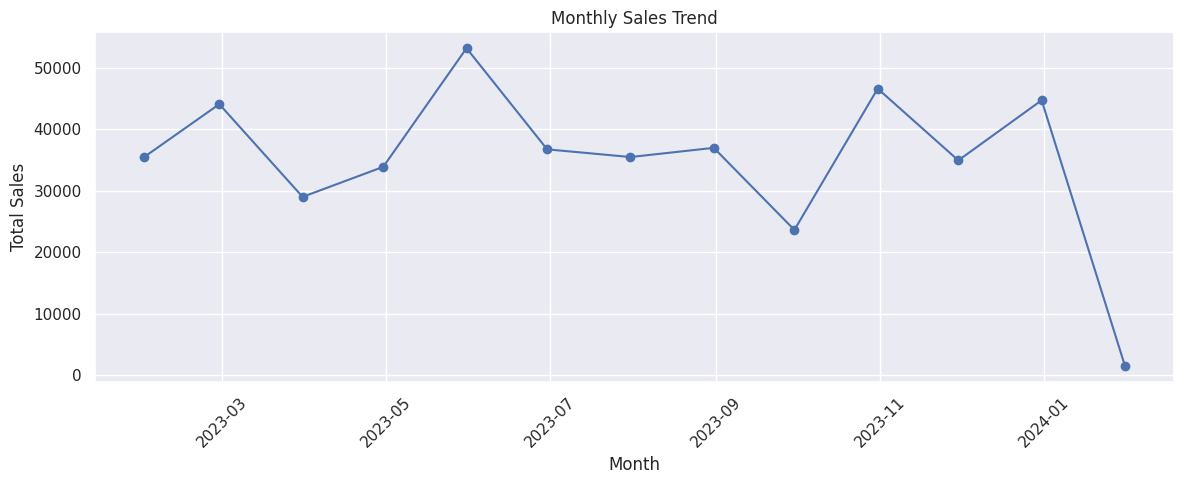

In [26]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_sales.index, monthly_sales.values, marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The monthly sales trend shows how total sales changed over time.
The line chart helps identify months with relatively higher or lower
sales activity and provides an overall view of sales fluctuations.

In [27]:
quarterly_sales = df.resample('QE', on='Date')['Total Amount'].sum()

quarterly_sales


,Total Amount
Date,
2023-03-31,108500
2023-06-30,123735
2023-09-30,96045
2023-12-31,126190
2024-03-31,1530


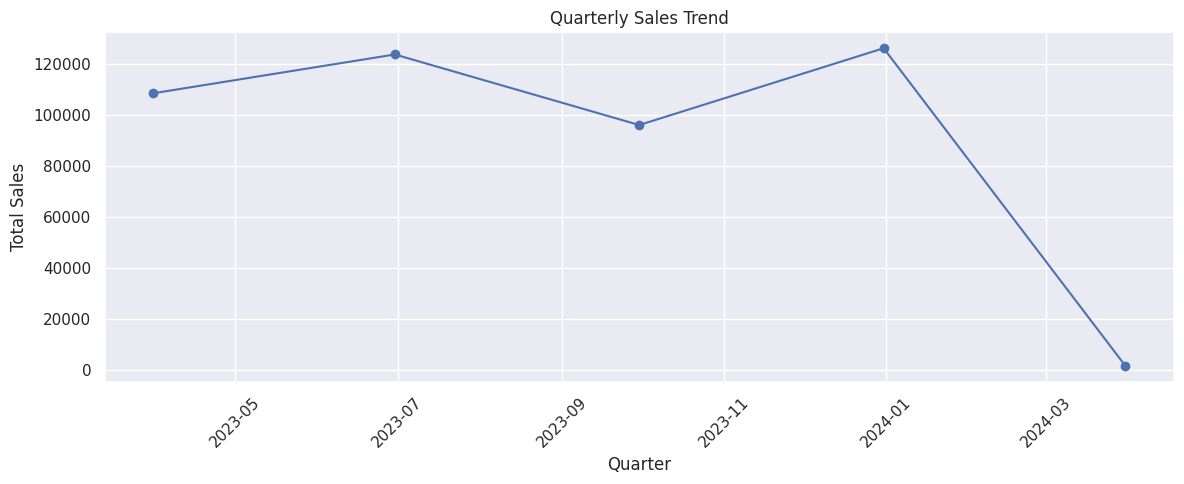

In [28]:
plt.figure(figsize=(12, 5))

plt.plot(quarterly_sales.index, quarterly_sales.values, marker='o')

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The quarterly sales trend provides a broader view of sales performance
by grouping transactions into three-month periods. It helps identify
which quarters experienced relatively higher or lower total sales.

## 4. Customer Demographics

This section analyzes customer demographics based on age and gender.
Age groups are created to understand the distribution of customers
across different age ranges, while gender analysis shows the overall
composition of male and female customers.

In [29]:
bins = [0, 18, 25, 35, 45, 55, 65, 100]

labels = [
    'Below 18',
    '18-25',
    '26-35',
    '36-45',
    '46-55',
    '56-65',
    'Above 65'
]

df['Age Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df['Age Group'].value_counts().sort_index()

,count
Age Group,
Below 18,21
18-25,148
26-35,205
36-45,202
46-55,229
56-65,195
Above 65,0


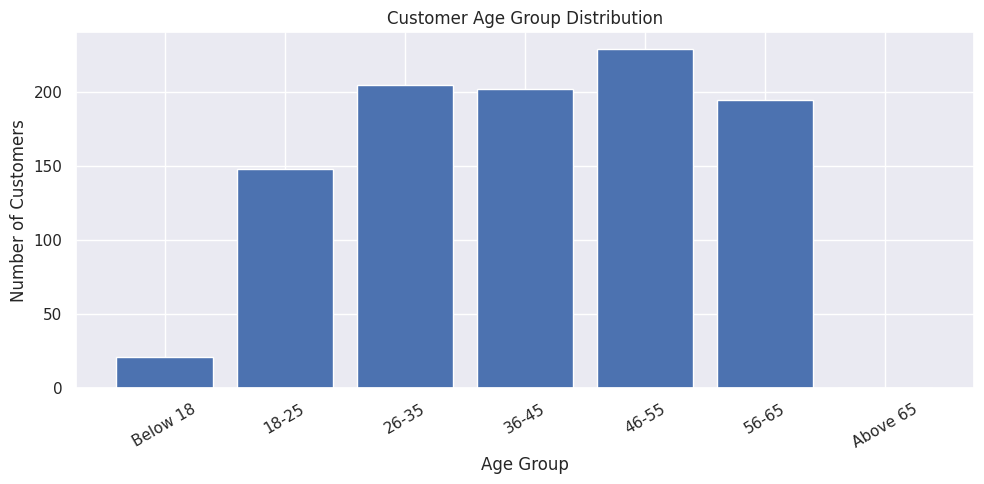

In [30]:
age_group_counts = df['Age Group'].value_counts().sort_index()

plt.figure(figsize=(10, 5))

plt.bar(age_group_counts.index, age_group_counts.values)

plt.title('Customer Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Observation

The age group distribution shows how customers are distributed across
different age ranges. This helps identify the major customer age groups
and can support age-based marketing and product targeting strategies.

In [31]:
gender_counts = df['Gender'].value_counts()

gender_counts


,count
Gender,
Female,510
Male,490


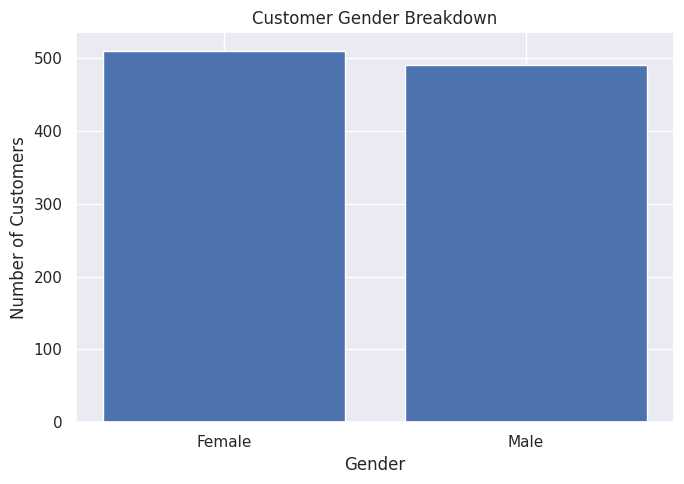

In [32]:
plt.figure(figsize=(7, 5))

plt.bar(gender_counts.index, gender_counts.values)

plt.title('Customer Gender Breakdown')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

### Observation

The gender breakdown shows the number of male and female customers
represented in the dataset. This information can help businesses
understand their customer composition and develop more targeted
marketing strategies.

## 5. Product Category Analysis

This section analyzes product category performance using quantity sold
and total revenue. Since the dataset does not contain individual product
names, the analysis is performed at the product category level.

In [33]:
category_quantity = (
    df.groupby('Product Category')['Quantity']
    .sum()
    .sort_values(ascending=False)
)

category_quantity

,Quantity
Product Category,
Clothing,894
Electronics,849
Beauty,771


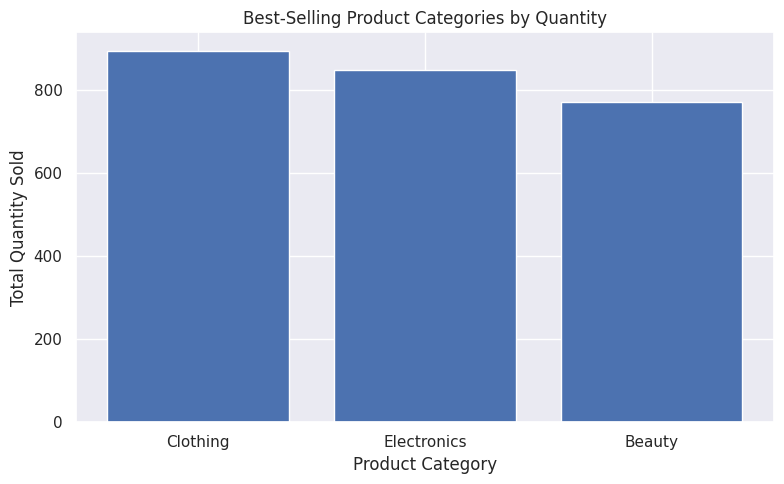

In [34]:
plt.figure(figsize=(8, 5))

plt.bar(category_quantity.index, category_quantity.values)

plt.title('Best-Selling Product Categories by Quantity')
plt.xlabel('Product Category')
plt.ylabel('Total Quantity Sold')

plt.tight_layout()
plt.show()

### Observation

The chart compares product categories based on total quantity sold.
The category with the highest quantity represents the strongest
volume-based sales performance, while lower quantities indicate
relatively lower product demand.

In [35]:
category_revenue = (
    df.groupby('Product Category')['Total Amount']
    .sum()
    .sort_values(ascending=False)
)

category_revenue

,Total Amount
Product Category,
Electronics,156905
Clothing,155580
Beauty,143515


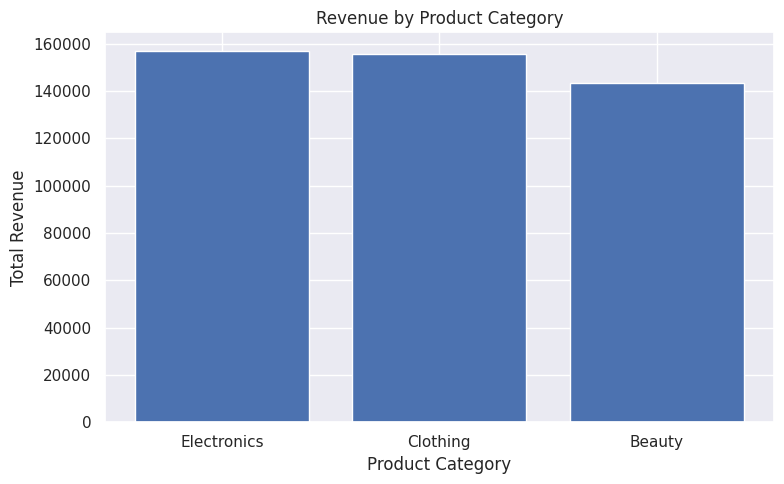

In [36]:
plt.figure(figsize=(8, 5))

plt.bar(category_revenue.index, category_revenue.values)

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')

plt.tight_layout()
plt.show()

### Observation

The revenue analysis shows the contribution of each product category
to overall sales revenue. Categories generating higher revenue can be
prioritized for inventory planning, promotions, and business growth.

### Dataset Limitation
**bold text**
The dataset does not contain an individual Product Name column.
Therefore, a Top 10 individual product analysis cannot be performed
without introducing unsupported or fabricated product information.
Instead, product performance is analyzed at the Product Category level.

## 6. Correlation Analysis

Correlation analysis is used to understand the relationship between
different numerical variables in the dataset. A heatmap is used to
visually represent the correlation matrix, where higher positive or
negative values indicate stronger relationships between variables.


In [37]:
correlation_matrix = df.corr(numeric_only=True)

correlation_matrix

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
Transaction ID,1.000000,0.065191,-0.026623,-0.060837,-0.075034
Age,0.065191,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.026623,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.060837,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.075034,-0.060568,0.373707,0.851925,1.000000


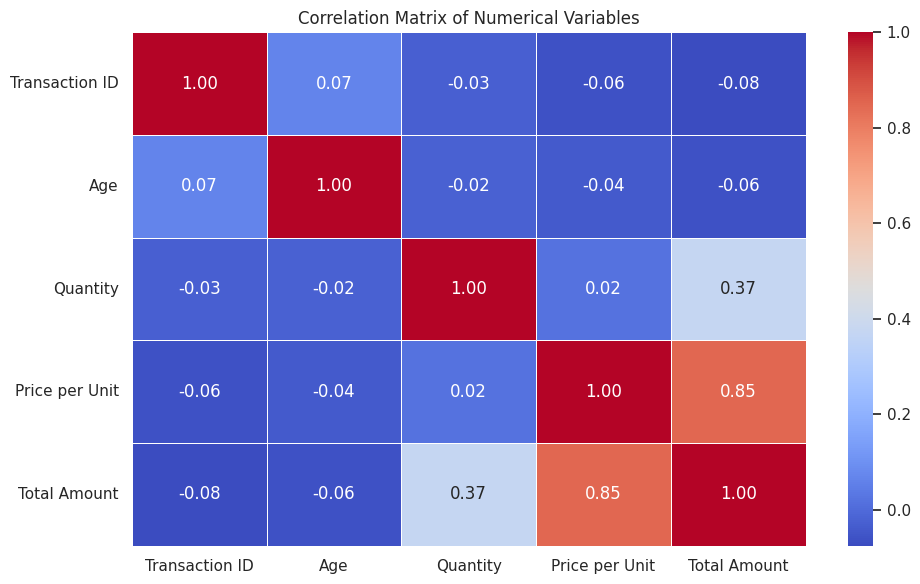

In [38]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()

### Observation

The correlation heatmap shows the strength and direction of relationships
among the numerical variables. The correlation values help identify
which variables have stronger positive or negative relationships and
which variables have relatively weak relationships.

## 7. Additional Visualization - Average Spending by Age Group

To identify an additional business insight, the average transaction
amount is compared across different customer age groups. This analysis
helps understand which age groups tend to spend more per transaction.

In [39]:
age_group_spending = (
    df.groupby('Age Group', observed=True)['Total Amount']
    .mean()
    .sort_values(ascending=False)
)

age_group_spending


,Total Amount
Age Group,
Below 18,534.047619
18-25,495.506757
26-35,480.390244
36-45,454.801980
46-55,439.694323
56-65,412.358974


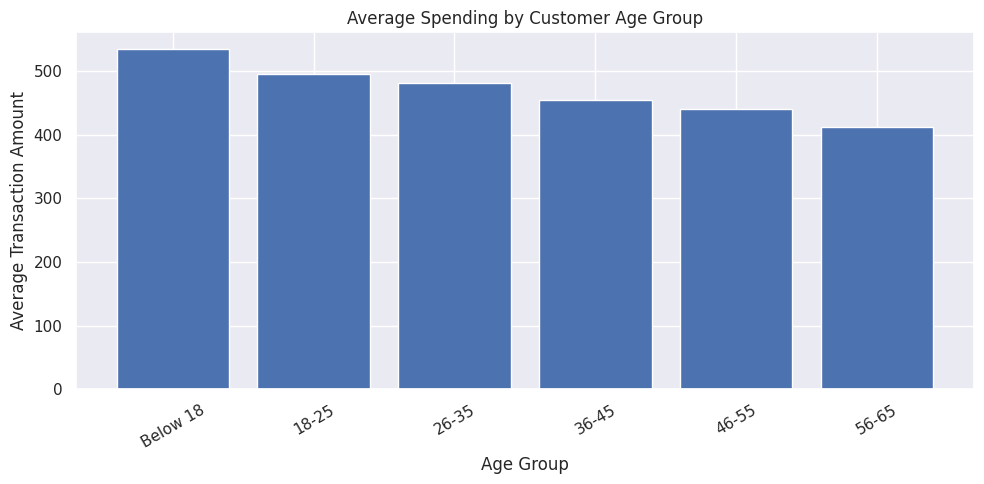

In [40]:
plt.figure(figsize=(10, 5))

plt.bar(age_group_spending.index, age_group_spending.values)

plt.title('Average Spending by Customer Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Transaction Amount')

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Observation

The visualization compares average transaction spending across customer
age groups. Differences in average spending indicate that some age groups
may have higher spending potential than others. This insight can help
businesses design age-specific promotions and customer targeting
strategies.

## 8. Conclusion and Business Recommendations

### Conclusion

The exploratory data analysis provided insights into retail sales
performance, customer demographics, product category performance, and
relationships between numerical variables. Monthly and quarterly sales
analysis helped identify changes in sales activity over time, while age
and gender analysis provided an understanding of the customer base.

Product category analysis showed differences in quantity sold and revenue
contribution across categories. The correlation analysis helped identify
relationships between numerical variables, and the additional age-group
spending analysis provided insight into differences in average transaction
value.

### Business Recommendations

1. **Focus on high-performing product categories:**  
   Product categories with higher sales volume and revenue should receive
   priority in inventory planning and promotional campaigns.

2. **Use customer demographics for targeted marketing:**  
   The business can create age-group-specific offers and marketing
   campaigns based on the customer distribution and average spending
   patterns.

3. **Improve sales planning using time-based trends:**  
   Monthly and quarterly sales trends can be used to plan inventory,
   promotions, staffing, and marketing activities during periods of
   higher or lower sales.

4. **Monitor customer spending behaviour:**  
   Differences in average transaction values across age groups can be
   monitored to develop targeted offers that encourage higher spending.

5. **Use data-driven inventory decisions:**  
   Quantity sold and revenue by product category can be regularly
   monitored to reduce the risk of overstocking low-performing categories
   and maintain sufficient inventory for high-demand categories.

## 9. Final Summary

This project demonstrated the use of Python, Pandas, Matplotlib, and
Seaborn to perform Exploratory Data Analysis on retail sales data.

The analysis covered data quality checking, descriptive statistics,
monthly and quarterly sales trends, customer demographics, product
category performance, revenue analysis, correlation analysis, and
additional customer spending insights.

The findings can support better decision-making related to marketing,
inventory management, customer targeting, and sales planning.